# Lab 2 — Best Practices for Programming Projects in AI


**Course:** Data Science: Principles and Applications  
**Session:** Essential Tools and Practices for Programming Projects in AI

**Main idea:** Transform familiar Open Food Facts analysis code into a project that is readable, reproducible, robust, documented, and collaborative.

## Learning objectives

- use an isolated Python environment and track dependencies;
- organize a Data Science project clearly;
- improve, refactor, and modularize Python code using functions and a small class;
- manage paths and configuration safely;
- handle an expected error;
- collaborate with Git and GitHub;
- document the project and reflect on responsible AI.

## Suggested timing

| Part | Topic | Time |
|---|---|---:|
| 1 | Setup, GitHub, and reproducibility | 25 min |
| 2 | Code quality and modularization | 45 min |
| 3 | GitHub collaboration and conflict resolution | 35 min |
| 4 | Documentation and responsible AI | 10 min |

**Total target: about 2 h**


# 1 — Project Setup and Reproducibility


## 1.1 Organize the project


1. Download the Lab 2 folder from Moodle.
2. Rename it `DSPAP_Lab2_YourName`.
3. Open the **complete folder** in VS Code.

The supplied notebook, data, configuration, and Python files are initially placed together in the project root. The destination folders are already present.

### Task

Using the VS Code Explorer, move each supplied file to its corresponding folder.


## 1.2 Connect GitHub and publish the project (Demo)


This section is completed together using the VS Code interface.

### Connect your GitHub account

If needed, create a GitHub account and verify its email address.

1. Press **Sign in** button in the top bar. 
2. Select **Continue with GitHub**.
3. Complete authentication and authorization in the browser.
4. Return to VS Code and confirm that the account is connected.

Configure your Git identity in the VS Code terminal:

```bash
git config --global user.name "FirstName LastName"
git config --global user.email "your.email@example.com"
```

> ⚠️ Use an email address associated with your GitHub account.

### Task

`.gitignore` tells Git which local, generated, temporary, or sensitive files must remain outside the repository.

1. Create a new **empty file** named `.gitignore` in the project root.
2. Add these general rules together:

```gitignore
# Virtual environments, independently of the chosen name
*venv*/


# Notebook, system, and generated output files
.ipynb_checkpoints/
.DS_Store
results/

# Local secrets
.env
```

### Initialize and publish

In the **Source Control** panel:

1. select **Initialize Repository**;
2. review and stage the supplied project files and the new `.gitignore`;
3. write a meaningful first commit message and commit;
4. select **Publish Branch** or **Publish to GitHub**;
5. create the repository and open it in the browser.


### ✅ Checkpoint

- GitHub is connected in VS Code.
- The repository has an initial commit and is published.
- `.gitignore` is tracked, while ignored files are absent from GitHub.


## 1.3 Create the project environment


### Task

Create `Lab2venv` in the project root.

#### Windows

```bash
python -m venv Lab2venv
Lab2venv\Scripts\activate
```

#### macOS / Linux

```bash
python3 -m venv Lab2venv
source Lab2venv/bin/activate
```

Open `requirements.txt` briefly, then install the project libraries:

```bash
python -m pip install -r requirements.txt
```

Select the interpreter and notebook kernel inside `Lab2venv`.

> ⚠️ A virtual environment contains generated, machine-specific files and can be recreated from `requirements.txt`. It should not be pushed to GitHub.

### Question

What should you verify so that `Lab2venv` is not included in commits?

<details>
<summary>Hint</summary>

Look for the general virtual-environment rule in `.gitignore`, add the exact env name to make sure that will not be ommited by the general rule. then check Source Control or `git status`.

</details>


In [1]:
import sys

print("Python executable:")
print(sys.executable)


Python executable:
c:\Users\chloe\Desktop\3A\dspap2026\TP2\Lab2venv\Scripts\python.exe


### ✅ Checkpoint

The displayed Python path contains `Lab2venv`.


## 1.4 Verify environment isolation


### Task

`colorama` is a very small package with no dependencies. Install a different version in each environment.

With `Lab2venv` active:

```bash
python -m pip install "colorama==0.4.5"
python -m pip show colorama
deactivate
```

Create and activate a second environment.

#### Windows

```bash
python -m venv Lab2venv_test
Lab2venv_test\Scripts\activate
```

#### macOS / Linux

```bash
python3 -m venv Lab2venv_test
source Lab2venv_test/bin/activate
```

Install the other version:

```bash
python -m pip install "colorama==0.4.6"
python -m pip show colorama
```

### Question

If you change the version in `Lab2venv_test`, does the version in `Lab2venv` change? Why?

<details>
<summary>Hint</summary>

The two environments use different package folders.

</details>

Before continuing, reactivate `Lab2venv`, select it as the notebook kernel, and remove the experiment-only package:

```bash
python -m pip uninstall -y colorama
```


### ✅ Checkpoint

- `Lab2venv` is active and selected as the notebook kernel.
- The project dependencies are installed.
- Both environment folders are ignored by Git.


# 2 — Improve an Existing Data Science Project


## 2.1 Imports and project root


### Task

Run the setup cell without modifying it.


In [2]:
# DO NOT MODIFY THIS CELL

from pathlib import Path
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "Notebooks" else CURRENT_DIR
DATASET_PATH = PROJECT_ROOT / "data" / "cleaned.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_PATH)


Project root: C:\Users\chloe\Desktop\3A\dspap2026\TP2
Dataset path: C:\Users\chloe\Desktop\3A\dspap2026\TP2\data\cleaned.csv


## 2.2 Improve a working PCA analysis


This code applies PCA to nutritional data to reduce its dimensionality and identify the main patterns across selected features. It works correctly, but its readability and structure need improvement. 
### Task

Run the intentionally imperfect cell, then rewrite it in three blocks:

- Block A: load and prepare the data;
- Block B: scale the features and run PCA;
- Block C: display the result and explained-variance plot.

Improve the code by applying Python best practices while **preserving the same analysis and results.**


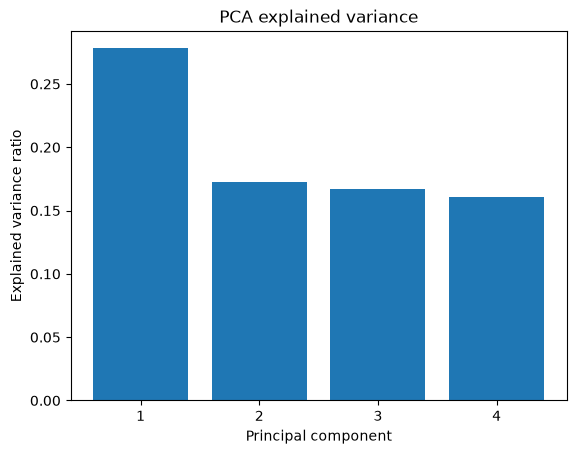

Dataset shape: (121501, 15)
PCA transformed shape: (121501, 4)


,PC1,PC2,PC3,PC4
sugars_100g,0.133721,-0.695724,-0.004165,0.688119
fat_100g,0.548348,-0.012242,0.001516,0.033712
salt_100g,0.055980,0.706894,-0.039826,0.700191
proteins_100g,0.630652,0.120821,0.005097,-0.160210
energy-kcal_100g,-0.004477,0.024861,0.999165,0.032100
fiber_100g,0.529676,-0.030038,0.006067,-0.091600


In [3]:
# Intentionally imperfect code — DO NOT improve this cell directly.

df = pd.read_csv(DATASET_PATH)
f = ["sugars_100g", "fat_100g", "salt_100g", "proteins_100g", "energy-kcal_100g", "fiber_100g"]
d = df[f].dropna()
x = d.values
s = StandardScaler()
x2 = s.fit_transform(x)
p = PCA(n_components=4)
x3 = p.fit_transform(x2)
NewDataset = pd.DataFrame(p.components_.T, index=f, columns=["PC1", "PC2", "PC3", "PC4"])
r = p.explained_variance_ratio_
plt.bar(range(1, len(r) + 1), r)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance")
plt.xticks(range(1, len(r) + 1))
plt.show()
print("Dataset shape:", df.shape)
print("PCA transformed shape:", x3.shape)
NewDataset


<details>
<summary>Hints</summary>

- reuse `DATASET_PATH` from the setup cell;
- choose meaningful `snake_case` names;
- name variables according to their role;
- keep formatting consistent.

</details>


In [4]:
# Block A — Load and prepare the data

# Load the data set
df_data = pd.read_csv(DATASET_PATH)
# Choose the features to work with
features = ["sugars_100g", "fat_100g", "salt_100g", "proteins_100g", "energy-kcal_100g", "fiber_100g"]
# Clean and gather the values in a separate list
df_data_cleaned = df_data[features].dropna()
features_values = df_data_cleaned.values


In [5]:
# Block B — Scale the features and run PCA

# Scale the values before runing pca
scaler = StandardScaler()
scaled_values = scaler.fit_transform(features_values)
# Run pca and store the values
pca = PCA(n_components=4)
transformed_values = pca.fit_transform(scaled_values)

Dataset shape: (121501, 15)
PCA transformed shape: (121501, 4)


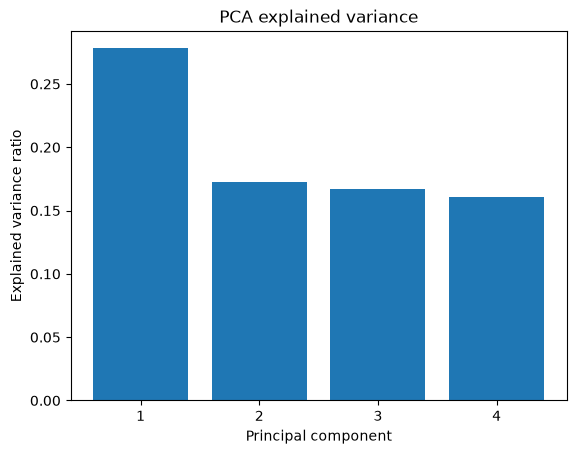

In [6]:
# Block C — Present the results

# Results as a new dataset
NewDataset = pd.DataFrame(pca.components_.T, index=features, columns=["PC1", "PC2", "PC3", "PC4"])
print("Dataset shape:", df_data.shape)
print("PCA transformed shape:", transformed_values.shape)
NewDataset

# Results as a graphic
explained_variance_ratio = pca.explained_variance_ratio_
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()


### ✅ Checkpoint

Choose a short, meaningful commit message, then commit and push your work.


## 2.3 Refactor reusable operations


The objective is to avoid repetition and make the PCA workflow reusable with other inputs.

### Task

Create:

- `run_pca(dataframe, feature_names, n_components)`, returning the fitted model, transformed data, and loadings;
- `plot_explained_variance(pca_model)`, displaying the bar chart.

Add short docstrings and test both functions.

<details>
<summary>Hints</summary>

Move working lines from the previous task into functions. Use parameters instead of notebook global variables.

</details>


In [7]:
# Block A — Define run_pca(...)

def run_pca(dataframe, feature_names, n_components):
    dataframe_cleaned = dataframe[feature_names].dropna() # Clean the dataframe and select only the information of the features chosen
    feature_values = dataframe_cleaned.values             # Retrive only the values of each features

    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(feature_values)  # Scale values before runing pca
    pca = PCA(n_components)
    transformed_values = pca.fit_transform(scaled_values) # New values for each features after runing pca
    return pca


In [8]:
# Block B — Define plot_explained_variance(...)

def plot_explained_variance(pca_model):
    explained_variance_ratio = pca_model.explained_variance_ratio_
    plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
    plt.xlabel("Principal component")
    plt.ylabel("Explained variance ratio")
    plt.title("PCA explained variance")
    plt.xticks(range(1, len(explained_variance_ratio) + 1))
    plt.show()

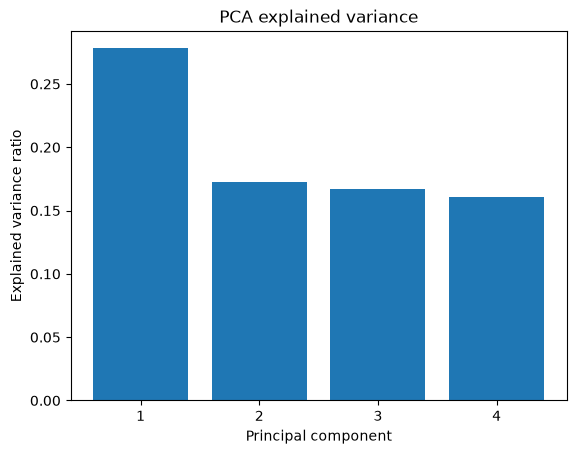

In [9]:
# Block C — Test both functions

pca_model = run_pca(df_data, features, 4)
plot_explained_variance(pca_model)


### ✅ Checkpoint

Choose a short, meaningful commit message, then commit and push your work.


## 2.4 Move reusable code to `src`


The objective is to separate reusable Python logic from notebook experimentation.

### Task

Move both functions and their required imports to `src/pca_utils.py`. Import them below and verify the same result.

> The analysis should change location, not behavior.


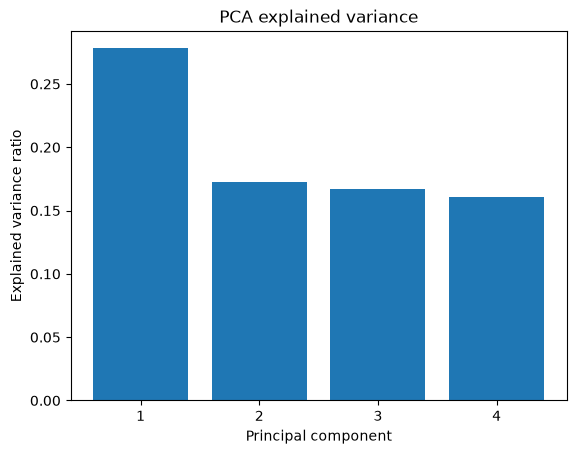

In [10]:
from SRC.pca_utils import run_pca, plot_explained_variance

# Run the analysis with the imported functions and verify the result.
pca_model = run_pca(df_data, features, 4)
plot_explained_variance(pca_model)

### Question

Why is `src/pca_utils.py` clearer than `my_tools.py`?

<details>
<summary>Hint</summary>

A module name should let a reader predict its purpose before opening it.

</details>

### ✅ Checkpoint

Choose a short, meaningful commit message, then commit and push your work.


src/pca_utils.py is clearer because we know the utils will be for PCA analysis. my_tools.py is too general and vague.

## 2.5 Use a class for nutrition analysis


The same food dataset is used for several analyses. A class groups this dataset and the operations that use it in one place.

`NutritionAnalyzer` is already available in `src/nutrition_summary.py`. Its `describe_features()` method can calculate general statistics for any numeric features you select.

### Task

- import `NutritionAnalyzer`;
- create one analyzer object using the food dataset you are working with;
- use `describe_features()` for sugars and proteins;
- reuse the same object to describe fat and salt.

<details>
<summary>Hint</summary>

Create the object once, then pass a different list of columns to `describe_features()`.

</details>


In [11]:
from src.nutrition_summary import NutritionAnalyzer

# Create one analyzer using the DataFrame prepared earlier.
# Your code here


ModuleNotFoundError: No module named 'src'

In [ ]:
# Describe sugars/proteins, then fat/salt.
# Your code here


### Question

Why is it useful for the analyzer object to keep the dataset?

<details>
<summary>Hint</summary>

Think about whether the dataset must be passed again for every analysis.

</details>

### ✅ Checkpoint

Choose a short, meaningful commit message, then commit and push your work.


## 2.6 Use configuration and robust paths


`DATASET_PATH` is sufficient for a fixed notebook. Configuration is useful when paths and experiment parameters must change without editing Python code.

### Task

Move the relative dataset path, feature list, and PCA component count into `config/config.yaml`, then load and use them.

Combine the relative `data/cleaned.csv` path with `PROJECT_ROOT`. Do not use `../data/cleaned.csv`.

<details>
<summary>Hints</summary>

Use `yaml.safe_load()`. Build `configured_dataset_path` from `PROJECT_ROOT` and the configured path, then reuse the functions from the reusable module.

</details>


In [ ]:
# Block A — Load configuration and resolve the data path

# Your code here


In [ ]:
# Block B — Run the configured analysis

# Your code here


### Task

Change only `pca.n_components` in `config/config.yaml` from `3` to `4`, rerun both blocks, and compare the bars and output shape. Restore `3` afterward.

<details>
<summary>Hint</summary>

Only the figure's component count and the transformed array's second dimension should change.

</details>


### ✅ Checkpoint

Choose a short, meaningful commit message, then commit and push your work.


## 2.7 Handle errors


The objective is to handle one expected failure clearly without hiding unrelated problems.

### Task

Create `load_dataset(csv_path)` that:

- returns the DataFrame when `pd.read_csv()` succeeds;
- catches only `FileNotFoundError`;
- prints a clear message containing the missing path;
- returns `None` when the file is absent.

Test it with the configured path and a nonexistent file.


In [ ]:
def load_dataset(csv_path):
    # Your code here
    pass


# Test the correct configured path and an intentionally wrong path.


### Question

Why is catching `FileNotFoundError` clearer than catching every error with `except Exception`?

<details>
<summary>Hint</summary>

Consider what happens to unrelated programming or data errors when every exception is caught.

</details>

### ✅ Checkpoint

Choose a short, meaningful commit message, then commit and push your work.


# 3 — Collaboration with GitHub


Work in **pairs**.

The objective is to practise parallel development in one shared repository. Both students extend the same `NutritionAnalyzer` class, but each develops a different method on their own branch. The pair then integrates both contributions and resolves one intentional conflict.

- Student 1 develops the sugar-summary method.
- Student 2 develops the protein-summary method.

> Resolve the conflict in `src/nutrition_summary.py`, not in the notebook, because notebooks are JSON files and are harder to merge manually.


## 3.1 Share and reproduce the project


### Task

### Student 1

Add Student 2 as a repository collaborator.

### Student 2

1. Clone the repository and open the complete folder in VS Code.
2. Recreate and activate `Lab2venv`.
3. Install `requirements.txt` and select `Lab2venv` as the notebook kernel.

### Question

What good practice has been tested?

<details>
<summary>Hint</summary>

Student 2 recreated the environment instead of copying Student 1's environment folder.

</details>


## 3.2 Create two branches


### Task

Choose **one** of the following methods.

### Option 1 — VS Code interface

1. Click the current branch name in the lower-left corner and select `main`.
2. In **Source Control**, use **Pull** or **Sync Changes** to update `main`.
3. Click the branch name again and select **Create new branch...**.
4. Enter `feature/sugar-summary` for Student 1 or `feature/protein-summary` for Student 2.
5. Confirm that the new active branch appears in the lower-left corner before editing.

### Option 2 — Terminal commands

#### Student 1

```bash
git switch main
git pull origin main
git switch -c feature/sugar-summary
git branch
```

#### Student 2

```bash
git switch main
git pull origin main
git switch -c feature/protein-summary
git branch
```

The `*` shown by `git branch` identifies the active branch.

Both students will modify:

`src/nutrition_summary.py`


## 3.3 Student 1 — Sugar contribution


### Task

On branch:

`feature/sugar-summary`

Add this method inside `NutritionAnalyzer`:

```python
def summarize_sugars(self):
    ...
```

It should return a dictionary containing:

- mean sugar;
- median sugar.

Then update the existing method:

```python
def build_nutrition_summary(self):
    ...
```

so that its returned dictionary contains the **sugar summary**.

Commit:

```bash
git add src/nutrition_summary.py
git commit -m "Add sugar nutrition summary"
git push -u origin feature/sugar-summary
```


## 3.4 Student 2 — Protein contribution


### Task

On branch:

`feature/protein-summary`

Add this method inside `NutritionAnalyzer`:

```python
def summarize_proteins(self):
    ...
```

It should return a dictionary containing:

- mean protein;
- median protein.

Then update the **same return statement** inside:

```python
def build_nutrition_summary(self):
    ...
```

so that its returned dictionary contains the **protein summary**.

Commit:

```bash
git add src/nutrition_summary.py
git commit -m "Add protein nutrition summary"
git push -u origin feature/protein-summary
```


## 3.5 Merge and resolve the conflict


### Task

Student 1 now integrates both contributions.

First, switch to `main`, bring it up to date, and merge Student 1's local branch:

```bash
git switch main
git pull origin main
git merge feature/sugar-summary
```

Next, fetch Student 2's remote branch and try to merge it:

```bash
git fetch origin
git merge origin/feature/protein-summary
```

Git should report a conflict because both branches started from the same version and changed the same return statement inside `build_nutrition_summary()` differently. Git cannot know which version—or which combination of both versions—matches the intended behavior.

#### Conflict-resolution instructions

Use the VS Code merge editor to inspect:

- **Current change**;
- **Incoming change**.

Do **not** simply choose one and delete the other.

The final class must preserve **both useful contributions**:

- sugar summary;
- protein summary.

After editing the file so that it keeps both summaries, mark the conflict as resolved, commit the merge, and push `main`:

```bash
git status
git add src/nutrition_summary.py
git commit -m "Resolve nutrition summary merge conflict"
git push origin main
```

### ✅ Checkpoint

Run the following after the merge:


In [ ]:
from src.nutrition_summary import NutritionAnalyzer

# Uncomment after the collaboration merge:
# collaboration_analyzer = NutritionAnalyzer(df)
# summary = collaboration_analyzer.build_nutrition_summary()
# summary


A correct final result contains information about **both sugars and proteins**.

### Question

Why could Git not decide automatically which return statement was correct?

<details>
<summary>Hint</summary>

Git can compare text changes, but it does not understand the intended program behavior.

</details>


# 4 — Documentation and Responsible AI


## 4.1 Create and complete the README



### Task

1. Create `README.md` manually in the project root.
2. Explain the project purpose, installation with `Lab2venv`, folder organization, notebook execution, and contributors.
3. Add your full name and your partner's full name.

### ✅ Checkpoint

Choose a meaningful commit message, then commit and push the completed README.


## 4.2 Short ethical reflection


### Task

Imagine the Open Food Facts analysis is used by an AI food-recommendation system. Write 1–2 sentences for each item:

1. one possible data bias;
2. one negatively affected stakeholder;
3. one mitigation;
4. one fact users should be told about how recommendations are produced.


### Task

**1. Possible bias:**  
...

**2. Affected stakeholder:**  
...

**3. Mitigation:**  
...

**4. Transparency:**  
...


# 5 — Final Checklist


### Environment and reproducibility

- [ ] `Lab2venv` is used for the project.
- [ ] The environment can be recreated with `requirements.txt`.
- [ ] Environment folders are not tracked by Git.

### Code quality

- [ ] Names are meaningful and use `snake_case`.
- [ ] Reusable functions have docstrings and are stored in `src/`.
- [ ] `NutritionAnalyzer` describes different feature combinations.
- [ ] Configurable values are in `config/config.yaml`.
- [ ] Dataset paths are resolved from the project root.
- [ ] A missing dataset is handled clearly.

### GitHub and documentation

- [ ] Commits use meaningful messages and are pushed.
- [ ] Both branches were merged while preserving both contributions.
- [ ] `README.md` explains how to install and run the project.
- [ ] `README.md` contains both pair members' names.

🎉 **Lab complete:** the project runs and is understandable, reproducible, maintainable, and shareable.

> ⚠️ **Important — Final task:** Write your full name and your partner's full name in `README.md`, then submit your completed work to Moodle.
